In [8]:
import pandas as pd
import seaborn as sb


**Pipeline overview:**
1. Load pre-engineered features from dataset vn_stocks_master_features.csv and vnindex_ohlcv.csv
2. Chronological 70 / 10 / 20 train–val–test split (NO shuffling)
3. `RobustScaler` fitted on training data only (no leakage)
4. Sliding-window sequence construction
5. Model training with `EarlyStopping` + `ReduceLROnPlateau` with loss function such as Huber loss function.
6. Evaluation: MAE, RMSE, MAPE — plus per-horizon degradation analysis

---
## Section 1 - Imports & Configuration

In [9]:
import sys
from pathlib import Path

# 1. Kết nối với Drive (Nếu trên Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/DL4AI-project')
    DATA_DIR = ROOT / 'data'
except ImportError:
    ROOT = Path.cwd().parent
    DATA_DIR = ROOT / 'notebooks' / 'data' / 'vietnam'

# 3. Kiểm tra xem folder có tồn tại không
if ROOT.exists():
    print(f"✓ Đã kết nối tới dự án tại: {ROOT}")
    # Cho phép Python tìm thấy các file trong folder src/
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
else:
    print(f"❌ Không tìm thấy folder dự án tại {ROOT}. Hãy kiểm tra lại tên folder trên Drive.")


ModuleNotFoundError: No module named 'google.colab'

In [10]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import matplotlib.dates as mdates
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
import joblib

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

# ── Project root logic (Tối ưu cho cả Local và Colab) ────────────────────────
try:
    from google.colab import drive
    # Nếu chạy trên Colab và đã mount Drive
    ROOT = Path('/content/drive/MyDrive/DL4AI-240166-project-1')
    print("✓ Running on Google Colab")
except ImportError:
    # Nếu chạy trên máy cá nhân
    ROOT = Path.cwd().parent
    print("✓ Running Locally")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


✓ Running Locally


In [ ]:
print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Project root: {ROOT}')

TensorFlow : 2.21.0
NumPy      : 2.4.3
Project root: /Users/cps/DL4AI-240166-project-1


---
### CONFIGURATIONS

In [11]:
CONFIG = {
    # ── Sequence construction ─────────────────────────────────────────────────
    'window_size'  : 20,    # look-back window: 2 trading days ≈ 1 calendar month
                            # Compared to 60 look-back window
    'n_features'   : 18,    # overwritten below after FEATURE_COLS is defined

    # ── Data split ratios ─────────────────────────────────────────────────────
    'train_ratio'  : 0.70,  # 70% of chronological data for training
    'val_ratio'    : 0.10,  # 10% for validation / hyperparameter tuning
    'test_ratio'   : 0.20,  # 20% held out for final evaluation

    # ── Training hyperparameters ──────────────────────────────────────────────
    'batch_size'   : 64,    # mini-batch size for gradient descent
    'epochs'       : 100,   # upper bound (EarlyStopping cuts this short)
    'learning_rate': 1e-3,  # Adam initial learning rate
    'patience'     : 10,    # EarlyStopping: max epochs without val_loss improvement

    # ── Dataset quality filter ────────────────────────────────────────────────
    'min_history'  : 120,   # discard tickers with fewer than 120 trading days

    # ── Forecasting horizons ──────────────────────────────────────────────────
    'n_day'        : 3,     # Task 2.2: predict the price n trading days ahead
    'k_days'       : 5,     # Task 2.3: predict the next k consecutive days
}

print('CONFIG:')
for k, v in CONFIG.items():
    print(f'  {k:<18} = {v}')

CONFIG:
  window_size        = 20
  n_features         = 18
  train_ratio        = 0.7
  val_ratio          = 0.1
  test_ratio         = 0.2
  batch_size         = 64
  epochs             = 100
  learning_rate      = 0.001
  patience           = 10
  min_history        = 120
  n_day              = 3
  k_days             = 5


### CONFIG Parameter Guide

| Parameter | Value | Rationale |
|---|---|---|
| `window_size` | 20 | 20 trading days ≈ 1 calendar months. 20 trading days ≈ 1 calendar month. More suitable for the short-term volatility characteristics of the VN-Index compared to a 60-day window. |
| `n_features` | 18 | Set dynamically from `FEATURE_COLS` after Section 3. The spec noted 13; actual pipeline produces 18 (6 OHLCV + 12 indicators). |
| `train_ratio` | 0.70 | 70/10/20 split for time-series. More training data reduces variance. |
| `val_ratio` | 0.10 | Drives EarlyStopping and ReduceLROnPlateau decisions. |
| `test_ratio` | 0.20 | **Never seen during training or hyperparameter search.** |
| `batch_size` | 64 | Balances training speed and gradient estimate quality. |
| `epochs` | 100 | Upper bound; EarlyStopping with `patience=10` terminates well before this. |
| `learning_rate` | 1e-3 | Adam default. `ReduceLROnPlateau` halves this if val_loss stagnates for 5 epochs. |
| `patience` | 10 | EarlyStopping: wait 10 epochs without improvement before terminating. |
| `min_history` | 120 | Filters tickers with insufficient history. |
| `n_day` | 3 | Task 2.2: primary evaluation at n=3; degradation also tested at n=1..7. |
| `k_days` | 5 | Task 2.3: one full trading week of consecutive predictions. |

---
## Section 2 - Data Loading & Ticker Filtering

In [ ]:
print(DATA_DIR)

/content/drive/MyDrive/DL4AI-project/data


In [12]:
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import matplotlib.dates as mdates
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
import joblib

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

# ── Project root logic (Tối ưu cho cả Local và Colab) ────────────────────────
try:
    from google.colab import drive
    ROOT = Path('/content/drive/MyDrive/DL4AI-project')
    print("✓ Running on Google Colab")
except:
    ROOT = Path.cwd().parent
    print("✓ Running Locally")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / 'notebooks'/'vietnam'

# ── Load the pre-engineered features CSV ──────────────────────────────────────
MASTER_PATH = DATA_DIR / 'vn_stocks_master_features.csv'
VNI_PATH    = DATA_DIR / 'csv'/ 'vnindex_ohlcv.csv'

assert MASTER_PATH.exists(), f'File not found: {MASTER_PATH}'
assert VNI_PATH.exists(), f'File not found: {VNI_PATH}'

# 1. Load Master Data (10 tickers)
df_all = pd.read_csv(MASTER_PATH)
df_all['date'] = pd.to_datetime(df_all['date'])
df_all = df_all.sort_values(['ticker', 'date']).reset_index(drop=True)

# 2. Load VN-Index
df_vni_raw = pd.read_csv(VNI_PATH)
df_vni_raw['date'] = pd.to_datetime(df_vni_raw['date'])
df_vni_raw = df_vni_raw.sort_values('date').reset_index(drop=True)

# ── VN-Index Multi-Feature Engineering ───────────────────────────────────────
def compute_vni_features(df):
    """
    Compute technical indicators for VN-Index, mirroring stock feature engineering.
    All output columns are prefixed with 'vni_' to avoid collisions after merge.
    """
    df = df.copy().sort_values('date').reset_index(drop=True)
    close = df['close']
    high  = df['high']
    low   = df['low']

    # Log return
    df['vni_log_return'] = np.log(close / close.shift(1))

    # EMA
    df['vni_ema_10'] = close.ewm(span=10, adjust=False).mean()
    df['vni_ema_20'] = close.ewm(span=20, adjust=False).mean()
    df['vni_ema_50'] = close.ewm(span=50, adjust=False).mean()

    # RSI (14)
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    df['vni_rsi'] = 100 - (100 / (1 + rs))

    # MACD (12/26/9)
    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    df['vni_macd']        = ema_12 - ema_26
    df['vni_macd_signal'] = df['vni_macd'].ewm(span=9, adjust=False).mean()
    df['vni_macd_hist']   = df['vni_macd'] - df['vni_macd_signal']

    # ATR (14)
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    df['vni_atr'] = tr.rolling(14).mean()

    # Bollinger Bands (20, 2σ)
    sma_20 = close.rolling(20).mean()
    std_20 = close.rolling(20).std()
    df['vni_bb_middle'] = sma_20
    df['vni_bb_upper']  = sma_20 + 2 * std_20
    df['vni_bb_lower']  = sma_20 - 2 * std_20

    vni_cols = [c for c in df.columns if c.startswith('vni_')]
    df[vni_cols] = df[vni_cols].fillna(0)   # fill leading NaNs from rolling windows

    return df[['date'] + vni_cols]

df_vni = compute_vni_features(df_vni_raw)

print(f'Loaded Master  : {df_all.shape[0]:,} rows | Tickers: {df_all["ticker"].unique()}')
print(f'VNI raw        : {df_vni_raw.shape[0]:,} rows')
print(f'VNI features   : {df_vni.shape[1] - 1} indicators → {[c for c in df_vni.columns if c != "date"]}')

# ── Filter by minimum history ─────────────────────────────────────────────────
ticker_counts = df_all.groupby('ticker').size()
valid_tickers = ticker_counts[ticker_counts >= CONFIG['min_history']].index.tolist()
df_filtered = df_all[df_all['ticker'].isin(valid_tickers)].copy()

# ── Primary ticker selection ──────────────────────────────────────────────────
PRIMARY_TICKER = 'FPT'
df = df_filtered[df_filtered['ticker'] == PRIMARY_TICKER].copy().reset_index(drop=True)

# ── Merge all VNI features into the primary ticker DataFrame ──────────────────
df = pd.merge(df, df_vni, on='date', how='left')

vni_feature_cols = [c for c in df_vni.columns if c != 'date']
nan_count = df[vni_feature_cols].isna().sum().sum()
if nan_count > 0:
    print(f'⚠ {nan_count} NaN values after VNI merge — filling with 0')
    df[vni_feature_cols] = df[vni_feature_cols].fillna(0)

print(f'\nPrimary Ticker : {PRIMARY_TICKER} ({len(df):,} rows)')
print(f'VNI features merged: {vni_feature_cols}')


✓ Running Locally


AssertionError: File not found: /Users/cps/DL4AI-240166-project-1/notebooks/vietnam/vn_stocks_master_features.csv

---


---
## Section 3 - Feature Engineering:

In [ ]:
# 1. Xem tất cả các cột đang có
print("Danh sách tất cả 47 cột:")
print(df_all.columns.tolist())
print("-" * 30)

# 2. Định nghĩa các cột CHẮC CHẮN KHÔNG PHẢI là Feature (Metadata & Targets)
# Anh thêm các cột target khác của Anh vào đây (ví dụ: next_1d_return, direction,...)
COLS_TO_IGNORE = [
    'date', 'ticker', 'next_1d_return', 'next_5d_return',
    'direction', 'log_return_target' # Tên target thực tế của Anh
]

# 3. Tự động lấy tất cả các cột còn lại làm Feature
# Ensure FEATURE_COLS is derived from the dataframe that already has vni_log_return
# Or, define it here without 'vni_log_return' and add it dynamically after the merge
FEATURE_COLS = [c for c in df.columns if c not in COLS_TO_IGNORE]

# Since vni_log_return is now merged into df in wAMGqsw7zs-M,
# it will be included if it's not in COLS_TO_IGNORE.
# No need to explicitly append it here anymore.

print(f"Số lượng Features tìm thấy: {len(FEATURE_COLS)}")
print("Các Features tiêu biểu:", FEATURE_COLS[:10], "...") # In ra 10 cái đầu xem thử

Danh sách tất cả 47 cột:
['date', 'open', 'high', 'low', 'close', 'volume', 'ticker', 'log_return', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'atr', 'ema_10', 'ema_20', 'ema_50', 'bb_upper', 'bb_middle', 'bb_lower', 'sent_mean', 'sent_max', 'sent_min', 'news_count', 'revenue', 'profit', 'lengthReport', 'eps', 'dilutedEPS', 'pe', 'dilutedPe', 'roe', 'roa', 'roic', 'grossProfitMargin', 'netProfitMargin', 'debtEquity', 'debtAsset', 'quickRatio', 'currentRatio', 'pb', 'bv', 'beta', 'dividendYield', 'financialLeverage', 'ttmType', 'asset', 'marketCap']
------------------------------
Số lượng Features tìm thấy: 46
Các Features tiêu biểu: ['open', 'high', 'low', 'close', 'volume', 'log_return', 'rsi', 'macd', 'macd_signal', 'macd_hist'] ...


In [ ]:
# The logic to add 'vni_log_return' to df and FEATURE_COLS has been moved to cell wAMGqsw7zs-M.
# This cell is now redundant.

# Update CONFIG (if FEATURE_COLS was modified in this step, but it's now handled earlier)
CONFIG['n_features'] = len(FEATURE_COLS)

print(f"✓ Updated n_features in CONFIG: {CONFIG['n_features']}")

In [ ]:
# Ví dụ lọc các cột liên quan đến RSI hoặc MACD
rsi_related = [c for c in df_all.columns if 'rsi' in c.lower()]
macd_related = [c for c in df_all.columns if 'macd' in c.lower()]
ema_related = [c for c in df_all.columns if 'ema' in c.lower()]

print(f"Tìm thấy {len(ema_related)} cột EMA: {ema_related}")
print(f"Tìm thấy {len(macd_related)} cột MACD: {macd_related}")
print(f"Tìm thấy {len(rsi_related)} cột RSI: {rsi_related}")


Tìm thấy 3 cột EMA: ['ema_10', 'ema_20', 'ema_50']
Tìm thấy 3 cột MACD: ['macd', 'macd_signal', 'macd_hist']
Tìm thấy 1 cột RSI: ['rsi']


In [ ]:

CONFIG['n_features'] = len(FEATURE_COLS)

# Target is the log-return because the close price is non-stationary, making the model
# prone to gradient vanishing
TARGET_COL = 'log_return'

print(f"✓ Defined Target: {TARGET_COL}")
print(f"✓ Number of Input Features: {len(FEATURE_COLS)}")
print(f"✓ Total n_features (Model Input): {CONFIG['n_features']}")

✓ Defined Target: log_return
✓ Number of Input Features: 46
✓ Total n_features (Model Input): 46


---
## Section 4 - Chronological Train/ Val/ Test Split

### Critical Rule: Never Shuffle Time-Series Data

Random shuffling is correct for i.i.d. datasets (images, NLP) but **catastrophically wrong**
for time series. Shuffling would:

1. **Destroy temporal structure**: the model would see future market state during training.
2. **Cause data leakage**: sliding windows would span train/test boundaries.
3. **Inflate metrics**: test performance would reflect interpolation, not genuine
   out-of-sample forecasting.

**Correct approach**: sort by date → split at chronological cut-points → build
sliding-window sequences *within each split separately* (implemented in Section 6).

In [ ]:
def chronological_split(df, train_ratio, val_ratio):
    """
    Split a time-ordered DataFrame into train / val / test subsets,
    ensuring no temporal overlap between the date ranges.
    """
    n = len(df)

    # Calculate approximate index-based split points
    approx_train_end_idx = int(n * train_ratio)
    approx_val_end_idx   = int(n * (train_ratio + val_ratio))

    # --- Determine the actual end index for the training set ---
    actual_train_end_idx = approx_train_end_idx
    if actual_train_end_idx < n:
        # Get the date of the last element in the approximate train split
        train_split_date_boundary = df.iloc[max(0, approx_train_end_idx - 1)]['date']

        # Find the first index where the date is strictly greater than this boundary date
        mask_after_train = df['date'] > train_split_date_boundary
        if mask_after_train.any():
            actual_train_end_idx = mask_after_train.idxmax()
        else:
            # If no date is strictly greater, it means all remaining data
            # has dates <= train_split_date_boundary. Assign all remaining to train.
            actual_train_end_idx = n

    # --- Determine the actual end index for the validation set ---
    actual_val_end_idx = approx_val_end_idx
    if actual_val_end_idx < n:
        # Get the date of the last element in the approximate val split
        # Ensure we don't try to access an index before actual_train_end_idx
        val_split_date_boundary_idx = max(actual_train_end_idx, approx_val_end_idx - 1)
        if val_split_date_boundary_idx < n:
            val_split_date_boundary = df.iloc[val_split_date_boundary_idx]['date']
            mask_after_val = df['date'] > val_split_date_boundary
            if mask_after_val.any():
                actual_val_end_idx = mask_after_val.idxmax()
            else:
                actual_val_end_idx = n
        else:
            actual_val_end_idx = n

    # Ensure that actual_val_end_idx is always >= actual_train_end_idx
    actual_val_end_idx = max(actual_train_end_idx, actual_val_end_idx)

    train_df = df.iloc[:actual_train_end_idx].copy()
    val_df   = df.iloc[actual_train_end_idx:actual_val_end_idx].copy()
    test_df  = df.iloc[actual_val_end_idx:].copy()

    return train_df, val_df, test_df

# Execute split on the Primary Ticker data
train_df, val_df, test_df = chronological_split(
    df, CONFIG['train_ratio'], CONFIG['val_ratio']
)

print(f'Train : {train_df["date"].min().date()} -> {train_df["date"].max().date()} ({len(train_df):,} rows)')
print(f'Val   : {val_df["date"].min().date()} -> {val_df["date"].max().date()} ({len(val_df):,} rows)')
print(f'Test  : {test_df["date"].min().date()} -> {test_df["date"].max().date()} ({len(test_df):,} rows)')

# Sanity check for temporal integrity
assert train_df['date'].max() < val_df['date'].min(), "Temporal overlap between Train and Val!"
assert val_df['date'].max() < test_df['date'].min(), "Temporal overlap between Val and Test!"
print('\n✓ Chronological integrity confirmed.')

Train : 2020-03-18 -> 2024-04-23 (5,130 rows)
Val   : 2024-04-24 -> 2024-11-20 (730 rows)
Test  : 2024-11-21 -> 2026-04-28 (1,466 rows)

✓ Chronological integrity confirmed.


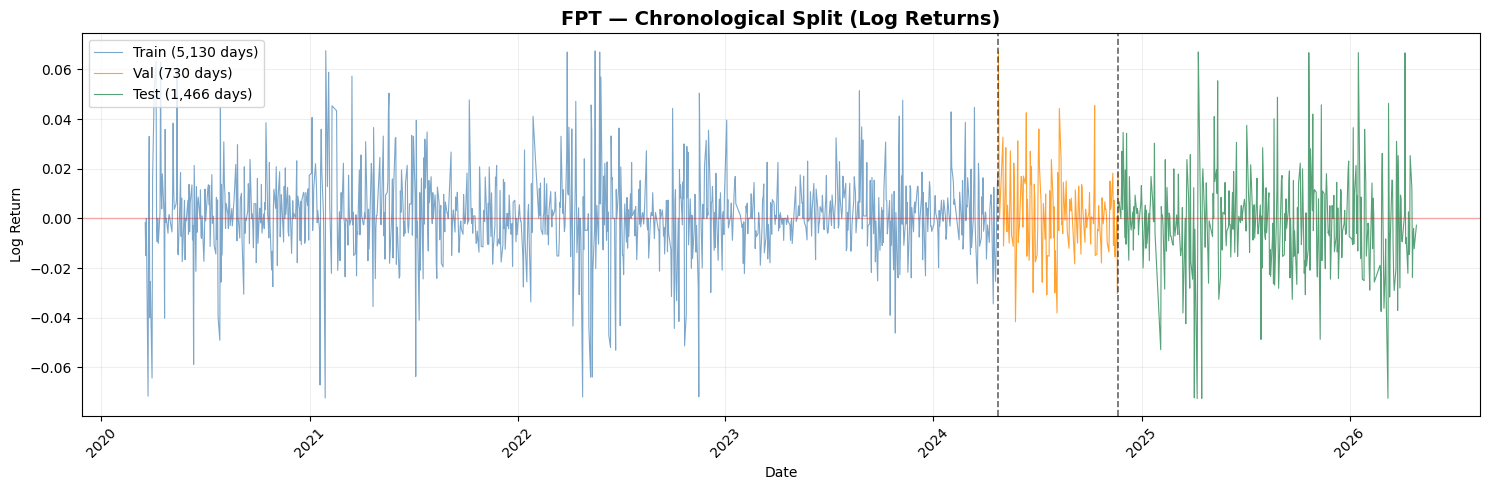

In [ ]:
# ── Visualise the three splits on one Log Return chart ────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))

# Use alpha to see density and high volatility spikes better
ax.plot(train_df['date'], train_df['log_return'],
        color='steelblue', label=f'Train ({len(train_df):,} days)', linewidth=0.8, alpha=0.7)
ax.plot(val_df['date'], val_df['log_return'],
        color='darkorange', label=f'Val ({len(val_df):,} days)', linewidth=0.8, alpha=0.8)
ax.plot(test_df['date'], test_df['log_return'],
        color='seagreen', label=f'Test ({len(test_df):,} days)', linewidth=0.8, alpha=0.8)

# Add a horizontal line at 0 for reference
ax.axhline(0, color='red', linestyle='-', alpha=0.3, linewidth=1)

# Borders for splits
for cut in [train_df['date'].max(), val_df['date'].max()]:
    ax.axvline(cut, color='black', linestyle='--', alpha=0.6, linewidth=1.2)

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=45)

ax.set_title(f'{PRIMARY_TICKER} — Chronological Split (Log Returns)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.legend(loc='upper left')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
## Section 5 - Normalization:

RobustScaler:

In [ ]:
# ROOT the orginal folder of the project
MODELS_DIR = ROOT / 'models'

# Create a place to store models
MODELS_DIR.mkdir(exist_ok=True)

In [ ]:
from sklearn.preprocessing import RobustScaler # Recommended for VN Stock
import joblib

# ── Section 5: Normalization (No Data Leakage) ───────────────────────────────

# Initialize scalers - RobustScaler is more resilient to market spikes
feature_scaler = RobustScaler()
target_scaler  = RobustScaler()

# 1. Fit & Transform ONLY on training data
# We transform the values and store them back in the DataFrame for consistency
train_df[FEATURE_COLS] = feature_scaler.fit_transform(train_df[FEATURE_COLS])
train_df[[TARGET_COL]] = target_scaler.fit_transform(train_df[[TARGET_COL]])

# 2. Transform validation and test sets using the training fitted parameters
val_df[FEATURE_COLS] = feature_scaler.transform(val_df[FEATURE_COLS])
val_df[[TARGET_COL]] = target_scaler.transform(val_df[[TARGET_COL]])

test_df[FEATURE_COLS] = feature_scaler.transform(test_df[FEATURE_COLS])
test_df[[TARGET_COL]] = target_scaler.transform(test_df[[TARGET_COL]])

# ── Persistence ──────────────────────────────────────────────────────────────
# Save scalers for Task 1.2, 1.3, and future Inference
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(feature_scaler, MODELS_DIR / 'vn_feature_scaler_robust.pkl')
joblib.dump(target_scaler,  MODELS_DIR / 'vn_target_scaler_robust.pkl')

print(f"✓ Normalization Complete using RobustScaler.")
print(f"Target Median: {target_scaler.center_[0]:.6f} | IQR: {target_scaler.scale_[0]:.6f}")

# Sanity Check
display(train_df[FEATURE_COLS].head(10))

---
## Section 6 - Sliding Window Sequence Builder

In [ ]:
# ── Task Parameters ──────────────────────────────────────────────────────────
W       = CONFIG['window_size'] # 20
N_DAY   = CONFIG['n_day']       # 3
K_DAYS  = CONFIG['k_days']      # 5 (Khuyên dùng 5 cho VN, nhưng giữ 7 nếu Anh muốn)
K_RANGE = list(range(1, K_DAYS + 1))

# ── Sliding Window Sequence Function ─────────────────────────────────────────
def create_sequences(feature_array, target_array, window_size, forecast_horizon):
    """
    Creates sliding window sequences from feature and target arrays.

    Args:
        feature_array (np.ndarray): Array of input features.
        target_array (np.ndarray): Array of target values.
        window_size (int): The number of past steps to use as input.
        forecast_horizon (int or list): The future step(s) to predict.
                                        If int, single step. If list, multi-step.

    Returns:
        tuple: (X, y) where X is the input sequences and y is the target sequences.
    """
    X, y = [], []
    n_samples = len(feature_array)

    if isinstance(forecast_horizon, int): # Single-step prediction
        for i in range(window_size, n_samples - forecast_horizon + 1):
            X.append(feature_array[i - window_size:i])
            y.append(target_array[i + forecast_horizon - 1])
    elif isinstance(forecast_horizon, list): # Multi-step prediction
        max_k = max(forecast_horizon)
        for i in range(window_size, n_samples - max_k + 1):
            X.append(feature_array[i - window_size:i])
            y.append(target_array[[i + k - 1 for k in forecast_horizon]])
    else:
        raise ValueError("forecast_horizon must be an int or a list of ints")

    return np.array(X), np.array(y)

def build_multi_ticker_sequences(df_split, vni_df, task_type='single'):
    """
    Builds sequences ticker by ticker to prevent cross-ticker data leakage.
    """
    all_X, all_y = [], []

    # 1. Group by ticker to handle each stock independently
    for ticker, group in df_split.groupby('ticker'):
        # 2. Extract features and target arrays for this specific ticker
        # Features already scaled in Section 5
        feat_arr = group[FEATURE_COLS].values
        tgt_arr  = group[[TARGET_COL]].values

        # 3. Create sequences using the logic discussed
        if task_type == 'single':
            X, y = create_sequences(feat_arr, tgt_arr, W, N_DAY)
        else:
            X, y = create_sequences(feat_arr, tgt_arr, W, K_RANGE)

        if len(X) > 0:
            all_X.append(X)
            all_y.append(y)

    return np.concatenate(all_X), np.concatenate(all_y)

# ── Execute Refined Construction ──────────────────────────────────────────────

# Task 2.2: Single-step (n=3)
X_train_22, y_train_22 = build_multi_ticker_sequences(train_df, df_vni, 'single')
X_val_22,   y_val_22   = build_multi_ticker_sequences(val_df,   df_vni, 'single')
X_test_22,  y_test_22  = build_multi_ticker_sequences(test_df,  df_vni, 'single')

# Task 2.3: Multi-step (k=5 or 7)
X_train_23, y_train_23 = build_multi_ticker_sequences(train_df, df_vni, 'multi')
X_val_23,   y_val_23   = build_multi_ticker_sequences(val_df,   df_vni, 'multi')
X_test_23,  y_test_23  = build_multi_ticker_sequences(test_df,  df_vni, 'multi')

# ── Summary Output ────────────────────────────────────────────────────────────
print(f'✓ Task 2.2 Sequences (n={N_DAY}):')
print(f'  X_train: {X_train_22.shape} | y_train: {y_train_22.shape}')
print(f'✓ Task 2.3 Sequences (k={K_DAYS}):')
print(f'  X_train: {X_train_23.shape} | y_train: {y_train_23.shape}')

✓ Task 2.2 Sequences (n=3):
  X_train: (5108, 20, 46) | y_train: (5108, 1)
✓ Task 2.3 Sequences (k=5):
  X_train: (5106, 20, 46) | y_train: (5106, 5, 1)


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Helper function to flatten 3D sequences into 2D for ML models
def flatten_sequences(X):
    # Reshape from (Samples, Window, Features) to (Samples, Window * Features)
    return X.reshape(X.shape[0], -1)

# Flattening Task 2.2 data
X_train_22_ml = flatten_sequences(X_train_22)
X_val_22_ml   = flatten_sequences(X_val_22)
X_test_22_ml  = flatten_sequences(X_test_22)

# Targets for Task 2.2 are already 2D (Samples, 1), we just need to flatten to 1D
y_train_22_ml = y_train_22.ravel()
y_val_22_ml   = y_val_22.ravel()
y_test_22_ml  = y_test_22.ravel()


# Flattening Task 2.3 data
X_train_23_ml = flatten_sequences(X_train_23)
X_val_23_ml   = flatten_sequences(X_val_23)
X_test_23_ml  = flatten_sequences(X_test_23)



print(f"Machine Learning Input Shape (Task 2.2): {X_train_22_ml.shape}")
print(f"Machine Learning Input Shape (Task 2.3): {X_train_23_ml.shape}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Helper function to flatten 3D sequences into 2D for ML models
def flatten_sequences(X):
    # Reshape from (Samples, Window, Features) to (Samples, Window * Features)
    return X.reshape(X.shape[0], -1)

# Flattening Task 2.2 data
X_train_22_ml = flatten_sequences(X_train_22)
X_val_22_ml   = flatten_sequences(X_val_22)
X_test_22_ml  = flatten_sequences(X_test_22)

# Targets for Task 2.2 are already 2D (Samples, 1), we just need to flatten to 1D
y_train_22_ml = y_train_22.ravel()
y_val_22_ml   = y_val_22.ravel()
y_test_22_ml  = y_test_22.ravel()


# Flattening Task 2.3 data
X_train_23_ml = flatten_sequences(X_train_23)
X_val_23_ml   = flatten_sequences(X_val_23)
X_test_23_ml  = flatten_sequences(X_test_23)



print(f"Machine Learning Input Shape (Task 2.2): {X_train_22_ml.shape}")
print(f"Machine Learning Input Shape (Task 2.3): {X_train_23_ml.shape}")

Machine Learning Input Shape (Task 2.2): (5108, 920)
Machine Learning Input Shape (Task 2.3): (5106, 920)


### Random Forest Regressor

## Rationale: Why Start with Random Forest?

### Performance Benchmark
Establishes a solid performance floor (MAE/RMSE). If a complex Deep Learning
model cannot outperform this baseline, the added complexity is not justified.

### Non-Linearity
Unlike linear models, Random Forest effectively captures non-linear relationships
and interactions between technical indicators without requiring strict statistical
assumptions.

### Robustness
Less sensitive to outliers and requires minimal hyperparameter tuning to produce
reliable results, making it an ideal "sanity check" for the data pipeline.

---

## Feature Importance & Interpretability

### Dimensionality Reduction
With 47+ features and a 20-day look-back window, Random Forest helps identify
signal from noise. Features with near-zero importance can be pruned to streamline
subsequent Deep Learning architectures.

### Time-Step Analysis
By analysing importance across the flattened window, we can determine which
specific days in the look-back period (e.g., *t*−1 vs. *t*−20) carry the most
predictive weight — a critical insight for designing the LSTM input sequence.

### Leakage Detection
Any feature exhibiting disproportionately high importance (e.g., >90%) serves as
a red flag for potential data leakage or look-ahead bias, and warrants immediate
investigation before proceeding to model training.

In [ ]:
# ── Task 2.2 Baseline: Predict Single Day ─────────────────────────────────────
print("Fitting Random Forest for Task 2.2 (n-th day)...")
rf_22 = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf_22.fit(X_train_22_ml, y_train_22_ml) # Predict one value

# ── Task 2.3 Baseline: Predict k-consecutive days ────────────────────────────
print("Fitting Random Forest for Task 2.3 (k-consecutive days)...")
rf_23 = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
# Chú ý: Random Forest mặc định hỗ trợ Multi-output, nên ta giữ nguyên y (Samples, k)
rf_23.fit(X_train_23_ml, y_train_23.reshape(y_train_23.shape[0], -1))

# ── Quick Evaluation ──────────────────────────────────────────────────────────
def evaluate_ml(model, X, y_true, task_name="Task"):
    y_pred = model.predict(X)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"[{task_name}] MAE: {mae:.6f} | RMSE: {rmse:.6f}")
    return y_pred

y_pred_22 = evaluate_ml(rf_22, X_test_22_ml, y_test_22_ml, "Baseline RF 2.2")
y_pred_23 = evaluate_ml(rf_23, X_test_23_ml, y_test_23.reshape(y_test_23.shape[0], -1), "Baseline RF 2.3")

Fitting Random Forest for Task 2.2 (n-th day)...
Fitting Random Forest for Task 2.3 (k-consecutive days)...
[Baseline RF 2.2] MAE: 0.766920 | RMSE: 1.215789
[Baseline RF 2.3] MAE: 0.870620 | RMSE: 1.305770


In [ ]:
from sklearn.linear_model import LinearRegression

# ── Task 2.2 Baseline: Linear Regression ──────────────────────────────────────
print("Training Linear Regression for Task 2.2...")
lr_22 = LinearRegression()
lr_22.fit(X_train_22_ml, y_train_22_ml)

# ── Task 2.3 Baseline: Linear Regression ──────────────────────────────────────
# Scikit-learn LR also supports multi-output (N, k)
print("Training Linear Regression for Task 2.3...")
lr_23 = LinearRegression()
lr_23.fit(X_train_23_ml, y_train_23.reshape(y_train_23.shape[0], -1))

def evaluate_simple(model, X, y_true, name):
    y_pred = model.predict(X)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name:25} | MAE: {mae:.6f}")
    return y_pred

y_pred_lr22 = evaluate_simple(lr_22, X_test_22_ml, y_test_22_ml, "Linear Regression 2.2")
y_pred_lr23 = evaluate_simple(lr_23, X_test_23_ml, y_test_23.reshape(y_test_23.shape[0], -1), "Linear Regression 2.3")

Training Linear Regression for Task 2.2...


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import xgboost as xgb

# ── Task 2.2: XGBoost ─────────────────────────────────────────────────────────
print("Training XGBoost for Task 2.2...")
xgb_22 = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    tree_method='hist', # Faster on large datasets
    random_state=42,
    n_jobs=-1
)
xgb_22.fit(X_train_22_ml, y_train_22_ml)

# ── Task 2.3: XGBoost (Wrapped for Multi-output) ─────────────────────────────
from sklearn.multioutput import MultiOutputRegressor

print("Training XGBoost for Task 2.3 (Multi-output)...")
xgb_base = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
xgb_23 = MultiOutputRegressor(xgb_base).fit(X_train_23_ml, y_train_23.reshape(y_train_23.shape[0], -1))

y_pred_xgb22 = evaluate_simple(xgb_22, X_test_22_ml, y_test_22_ml, "XGBoost 2.2")
y_pred_xgb23 = evaluate_simple(xgb_23, X_test_23_ml, y_test_23.reshape(y_test_23.shape[0], -1), "XGBoost 2.3")

#### Evaluate

In [ ]:
def plot_prediction_analysis(y_true, y_pred, title="Model Evaluation"):
    # Chuyển ngược từ Scaled về Original Log Return (nếu cần)
    # y_true_orig = target_scaler.inverse_transform(y_true)
    # y_pred_orig = target_scaler.inverse_transform(y_pred)

    plt.figure(figsize=(15, 6))
    plt.plot(y_true[-100:], label='Actual Log Return', color='black', linewidth=1.5, alpha=0.7)
    plt.plot(y_pred[-100:], label='Predicted Log Return', color='red', linestyle='--', linewidth=1.5)

    plt.title(f'{title} - Last 100 Days Analysis', fontsize=14)
    plt.xlabel('Time Steps (Test Set)')
    plt.ylabel('Log Return')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Sử dụng cho XGBoost
plot_prediction_analysis(y_test_22, y_pred_xgb22, "XGBoost Task 2.2")

In [ ]:
errors = y_test_22.ravel() - y_pred_xgb22.ravel()
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title('Error Distribution (Residuals) for XGBoost Task 2.2')
plt.show()

In [ ]:
def plot_multi_step_path(y_true, y_pred, sample_idx):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, K_DAYS + 1), y_true[sample_idx], marker='o', label='Actual Path', color='black')
    plt.plot(range(1, K_DAYS + 1), y_pred[sample_idx], marker='s', label='Predicted Path', color='red', linestyle='--')

    plt.title(f'Multi-Day Forecast for Task 2.3 (Starting from Sample {sample_idx})')
    plt.xlabel('Days Ahead')
    plt.ylabel('Log Return')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Vẽ thử một mẫu bất kỳ cho Task 2.3
plot_multi_step_path(y_test_23.reshape(y_test_23.shape[0], -1), y_pred_xgb23, sample_idx=50)

In [ ]:
# Đánh giá cho Task 2.2 (n=3) - Price Prediction
# Bước 1: Nghịch đảo Scaling cho Target
y_test_orig = target_scaler.inverse_transform(y_test_22)
y_pred_orig = target_scaler.inverse_transform(y_pred_xgb22.reshape(-1, 1))

# Bước 2: Lấy giá Close tại thời điểm hiện tại (t) để tính cho (t+3)
# Lưu ý: Anh cần lấy đúng mảng giá close tương ứng với tập Test
current_close = test_df['close'].values[W : len(test_df) - N_DAY + 1]

# Bước 3: Tính giá dự báo và giá thực tế
price_actual = current_close * np.exp(y_test_orig.flatten())
price_pred   = current_close * np.exp(y_pred_orig.flatten())

# ── Visualizing Actual vs Predicted Prices ────────────────────────────────────
plt.figure(figsize=(15, 6))
plt.plot(price_actual[-100:], label='Actual Close Price', color='blue', linewidth=2)
plt.plot(price_pred[-100:], label='Predicted Close Price', color='red', linestyle='--', linewidth=1.5)
plt.title(f'{PRIMARY_TICKER} - Price Prediction for Task 2.2 (USD/VND) - Last 100 Days', fontsize=14)
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Tính xem model đoán đúng hướng bao nhiêu %
actual_dir = np.sign(y_test_orig.flatten())
pred_dir   = np.sign(y_pred_orig.flatten())
da_score   = np.mean(actual_dir == pred_dir)

print(f"Directional Accuracy: {da_score:.2%}")

---
## Section - Build Deep Learning models

In [ ]:
def build_seq2seq_attention(window_size, n_features, output_steps, name='seq2seq_attention'):
    """
    Encoder-Decoder GRU với Multi-Head Attention.
    Thích hợp nhất cho Task 1.3: Dự báo quỹ đạo 5-7 ngày.
    """
    # --- ENCODER ---
    inputs = tf.keras.Input(shape=(window_size, n_features), name='input')

    # GRU trích xuất đặc trưng chuỗi
    encoder_seq, encoder_state = tf.keras.layers.GRU(
        128, return_sequences=True, return_state=True, name='encoder_gru')(inputs)

    # Attention Layer giúp Encoder tập trung vào các phiên quan trọng trong quá khứ
    attention = tf.keras.layers.MultiHeadAttention(
        num_heads=4, key_dim=32, name='attention')(encoder_seq, encoder_seq)

    # Tổng hợp thông tin từ Attention
    context_vector = tf.keras.layers.GlobalAveragePooling1D()(attention)

    # --- BRIDGE ---
    # Lặp lại vector ngữ cảnh cho k ngày dự báo
    x = tf.keras.layers.RepeatVector(output_steps, name='bridge')(context_vector)

    # --- DECODER ---
    # Dùng encoder_state làm "mầm" cho bộ nhớ của Decoder
    x = tf.keras.layers.GRU(
        128, return_sequences=True, name='decoder_gru')(x, initial_state=encoder_state)

    x = tf.keras.layers.Dropout(0.2, name='dropout')(x)

    # Dự báo giá trị cho từng ngày trong chuỗi k ngày
    outputs = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1), name='time_dist_dense')(x)

    # Reshape (batch, k, 1) -> (batch, k)
    outputs = tf.keras.layers.Reshape((output_steps,), name='output')(outputs)

    model = tf.keras.Model(inputs, outputs, name=name)
    return model

# ── Initialization ────────────────────────────────────────────────────────────
model_s2s_attn = build_seq2seq_attention(
    window_size=CONFIG['window_size'],
    n_features=CONFIG['n_features'],
    output_steps=CONFIG['k_days']
)
model_s2s_attn.summary()

In [ ]:
def compile_and_train_vn(model, X_tr, y_tr, X_va, y_va, save_name):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
        loss='mse',
        metrics=['mae']
    )

    save_path = MODELS_DIR / f'{save_name}.keras'

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=CONFIG['patience'], restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            str(save_path), monitor='val_loss', save_best_only=True, verbose=0)
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=CONFIG['epochs'],
        batch_size=CONFIG['batch_size'],
        callbacks=callbacks,
        verbose=1
    )
    return history

# ── Run Training for Task 2.3 ─────────────────────────────────────────────────
history_s2s = compile_and_train_vn(
    model_s2s_attn, X_train_23, y_train_23, X_val_23, y_val_23, "s2s_attn_vn_task23"
)